In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import statsmodels.api as sm

from statsmodels.tsa.stattools import (
    coint,
    adfuller
)

import warnings

warnings.filterwarnings("ignore")

data = pd.read_csv(
    "nifty_50_comp_price_data.csv",
    index_col=0,
    parse_dates=True
)



data = data.dropna(axis=1)

selected_pairs = pd.read_csv(
    "selected_pairs_train.csv"
)

selected_pairs.head()


,Stock1,Stock2,Correlation,Cointegration_P,ADF_P
0,AXISBANK.NS,INDUSINDBK.NS,0.586723,0.000038,0.000004
1,INDUSINDBK.NS,SHRIRAMFIN.NS,0.476235,0.000858,0.000132
2,INDUSINDBK.NS,LT.NS,0.485595,0.001909,0.000303
3,ICICIBANK.NS,INDUSINDBK.NS,0.559069,0.002216,0.000311
4,M&M.NS,MARUTI.NS,0.524620,0.002486,0.000434


In [2]:
train = data.loc[
    :"2023-12-31"
]

test = data.loc[
    "2024-01-01":
]

In [3]:
def backtest_pair_walkforward(
    stock1,
    stock2,
    train,
    test,
    window=252,
    entry_z=2,
    exit_z=0
):

    combined = pd.concat([
        train[[stock1, stock2]],
        test[[stock1, stock2]]
    ])

    rolling_beta = (
        combined[stock1]
        .rolling(window)
        .cov(combined[stock2])
        /
        combined[stock2]
        .rolling(window)
        .var()
    )

    spread = (
        combined[stock1]
        - rolling_beta * combined[stock2]
    )

    rolling_mean = (
        spread
        .rolling(window)
        .mean()
    )

    rolling_std = (
        spread
        .rolling(window)
        .std()
    )

    zscore = (
        spread
        - rolling_mean
    ) / rolling_std

    zscore = zscore.loc[
        test.index
    ]

    beta_test = rolling_beta.loc[
        test.index
    ]

    position = pd.Series(
        0,
        index=test.index
    )

    current_position = 0

    for i in range(len(zscore)):

        z = zscore.iloc[i]

        if np.isnan(z):
            continue

        if current_position == 0:

            if z > entry_z:
                current_position = -1

            elif z < -entry_z:
                current_position = 1

        elif current_position == 1:

            if z >= exit_z:
                current_position = 0

        elif current_position == -1:

            if z <= -exit_z:
                current_position = 0

        position.iloc[i] = current_position

    stock1_ret = (
        test[stock1]
        .pct_change()
    )

    stock2_ret = (
        test[stock2]
        .pct_change()
    )

    spread_ret = (
        stock1_ret
        -
        beta_test * stock2_ret
    )

    strategy_ret = (
        position.shift(1)
        *
        spread_ret
    )

    return strategy_ret.fillna(0)

In [4]:
pair_returns = pd.DataFrame()

for _, row in selected_pairs.iterrows():

    stock1 = row["Stock1"]
    stock2 = row["Stock2"]

    pair_name = (
        f"{stock1}_{stock2}"
    )

    pair_returns[pair_name] = (
        backtest_pair_walkforward(
            stock1,
            stock2,
            train,
            test
        )
    )

pair_returns.head()

,AXISBANK.NS_INDUSINDBK.NS,INDUSINDBK.NS_SHRIRAMFIN.NS,INDUSINDBK.NS_LT.NS,ICICIBANK.NS_INDUSINDBK.NS,M&M.NS_MARUTI.NS,GRASIM.NS_INDUSINDBK.NS,SBILIFE.NS_TITAN.NS,ADANIPORTS.NS_GRASIM.NS,HINDUNILVR.NS_TATACONSUM.NS,HDFCBANK.NS_INDUSINDBK.NS
Date,,,,,,,,,,
2024-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000
2024-01-02,0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0,-0.000350
2024-01-03,-0.0,-0.0,0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,0.015180
2024-01-04,0.0,-0.0,0.0,-0.0,-0.0,-0.0,0.0,0.0,-0.0,-0.011097
2024-01-05,0.0,-0.0,-0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.005149


In [5]:
active_pairs = (
    pair_returns != 0
).sum(axis=1)

portfolio_ret = (
    pair_returns.sum(axis=1)
    /
    active_pairs.replace(
        0,
        np.nan
    )
)

portfolio_ret = portfolio_ret.fillna(0)

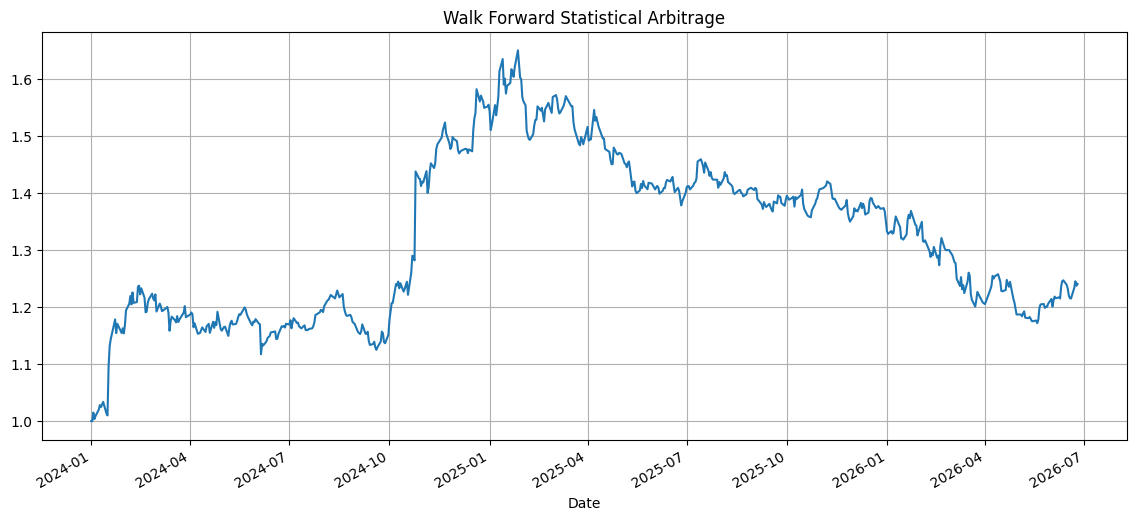

In [6]:
equity_curve = (
    1 + portfolio_ret
).cumprod()

plt.figure(figsize=(14,6))

equity_curve.plot()

plt.title(
    "Walk Forward Statistical Arbitrage"
)

plt.grid(True)

plt.show()

In [7]:
total_return = (
    equity_curve.iloc[-1] - 1
)

years = (
    len(portfolio_ret)
    / 252
)

cagr = (
    equity_curve.iloc[-1]
) ** (1 / years) - 1

sharpe = (
    portfolio_ret.mean()
    /
    portfolio_ret.std()
) * np.sqrt(252)

rolling_max = (
    equity_curve.cummax()
)

drawdown = (
    equity_curve
    / rolling_max
    - 1
)

max_dd = drawdown.min()

print(
    f"Total Return: {total_return:.2%}"
)

print(
    f"CAGR: {cagr:.2%}"
)

print(
    f"Sharpe: {sharpe:.2f}"
)

print(
    f"Max Drawdown: {max_dd:.2%}"
)

Total Return: 24.08%
CAGR: 9.24%
Sharpe: 0.58
Max Drawdown: -29.02%


In [8]:
walk_forward_results = pd.DataFrame({
    "Metric":[
        "Total Return",
        "CAGR",
        "Sharpe",
        "Max Drawdown"
    ],
    "Value":[
        total_return,
        cagr,
        sharpe,
        max_dd
    ]
})

walk_forward_results.to_csv(
    "walk_forward_results.csv",
    index=False
)

walk_forward_results

,Metric,Value
0,Total Return,0.240785
1,CAGR,0.092428
2,Sharpe,0.576661
3,Max Drawdown,-0.290169


In [9]:
pair_returns.sum().sort_values(
    ascending=False
)

GRASIM.NS_INDUSINDBK.NS        0.929863
INDUSINDBK.NS_SHRIRAMFIN.NS    0.775975
SBILIFE.NS_TITAN.NS            0.218969
INDUSINDBK.NS_LT.NS            0.084949
ICICIBANK.NS_INDUSINDBK.NS     0.060249
AXISBANK.NS_INDUSINDBK.NS      0.009563
M&M.NS_MARUTI.NS              -0.076760
HDFCBANK.NS_INDUSINDBK.NS     -0.196337
HINDUNILVR.NS_TATACONSUM.NS   -0.287625
ADANIPORTS.NS_GRASIM.NS       -0.290516
dtype: float64